# Agent-based Simulation with MESA
Mesa allows users to quickly create agent-based models using built-in core components (such as spatial grids and agent schedulers) or customized implementations; visualize them using a browser-based interface; and analyze their results using Python’s data analysis tools.

## Set up
**!!Make sure using the env launching Jupyter lab matching the kernel env!!**

[Installation guide](https://mesa.readthedocs.io/latest/index.html) on Mesa's official website.  
Use Conda(https://anaconda.org/conda-forge/mesa) to install for manageability in controlled environment.  
Install [Solara](https://solara.dev/) for interactive visulization(`ipyvuetify`&`ipyvue` needed).
- Run `python -V` in terminal to check Python version.  
- Run `conda install - c conda-forge mesa solara altair` to install packages.  
- Check their versions by running `conda list solara` & `conda list mesa`.
- Check Jupyter extensions: `jupyter labextension list`
- Remember to restart the kernel.

### Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import mesa
# Import Cell Agent and OrthogonalMooreGrid
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid
from mesa.visualization import SolaraViz, make_plot_component, make_space_component

In [2]:
import solara
solara.check_jupyter()

In [3]:
import sys
print(sys.executable)

/opt/miniconda3/envs/my_env/bin/python


## Create Agent
Follow the [tutorial](https://mesa.readthedocs.io/latest/tutorials/0_first_model.html) from Mesa document.  
This particular case simulate an economy with agents as consumer or producer exanging money. [[Drăgulescu, 2002](https://arxiv.org/abs/cond-mat/0211175)]. 

An agent has a initial state and actions defined with functions.  
`exchange`: the agent will check its wealth, and if it has money, give one unit of it away to another random agent.

In [9]:
# Instantiate MoneyAgent as CellAgent
# class MoneyAgent(mesa.Agent):
class MoneyAgent(CellAgent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, cell, ethnicity):
        super().__init__(model)
        self.cell = cell  # Instantiate agent with location (x,y)
        self.wealth = 1
        self.ethnicity = ethnicity
        
    def say_hi(self):
        # The agent's step will go here.
        # For demonstration purposes we will print the agent's unique_id
        print(f"Hi, I am an agent, you can call me {self.unique_id!s}.")
        
    def say_wealth(self):
        print(f"my wealth is {self.wealth}")

    # Move Function
    def move(self):
        self.cell = self.cell.neighborhood.select_random_cell()
    
    # The new function only gives money to poor agents
    def give_money_a(self, poor_agents):
        if self.wealth > 0:
            other_agent = self.random.choice(poor_agents)
            other_agent.wealth += 1
            self.wealth -= 1            
    # exchange money based on ethnicity        
    def give_money_b(self, similars):
        if self.wealth > 0:
            other_agent = self.random.choice(similars)
            other_agent.wealth += 1
            self.wealth -= 1
    
    """ ---------------- Obsolete ----------------
    def give_money(self):
        cellmates = [
            a for a in self.cell.agents if a is not self
        ]  # Get all agents in cell

        if self.wealth > 0 and cellmates:
            other_agent = self.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1
            
    def exchange(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1
    """

## Create Model
A model is a set of agents.  
Use `step` function to tell agent what to do in one smallest unit of time(tick/step) in the model.

In [26]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, width=10, height=10, seed=None):
        """Initialize a MoneyModel instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        
        # Instantiate an instance of Moore neighborhood space
        self.grid = OrthogonalMooreGrid(
            (width, height), torus=True, capacity=10, random=self.random
        )

        # Create a list of our different ethnicities
        ethnicities = ["Green", "Blue", "Mixed"]

        # Create agents
        # MoneyAgent.create_agents(model=self, n=n)
        agents = MoneyAgent.create_agents(
            self,
            self.num_agents,
            # Randomly select agents cell
            self.random.choices(self.grid.all_cells.cells, k=self.num_agents),
            ethnicity=self.random.choices(ethnicities, k=self.num_agents),
        )

        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, agent_reporters={"Wealth": "wealth", "Ethnicity": "ethnicity"}
        )

    def step(self):
        """Advance the model by one step."""
        # This function psuedo-randomly reorders the list of agent objects and
        # then iterates through calling the function passed in as the parameter   
        
        # Collect data each step
        self.datacollector.collect(self)
        
        self.agents.shuffle_do("move")
        # Create dictionary of agents groupby
        grouped_agents = model.agents.groupby("ethnicity")
        for ethnic, similars in grouped_agents:
            if ethnic != "Mixed":
                similars.shuffle_do("give_money_b", similars)
            else:
                similars.shuffle_do(
                    "give_money_b", self.agents
                )  # This allows mixed to trade with anyone

        """ ---------------- Obsolete ----------------      
        # Get lists of rich and poor agents
        rich_agents = model.agents.select(lambda a: a.wealth >= 3)
        poor_agents = model.agents.select(lambda a: a.wealth < 3)
        # When there is rich agents only have them give money to poor agents
        if len(rich_agents) > 0:
            rich_agents.shuffle_do("give_money_a", poor_agents)
        else:
            poor_agents.shuffle_do("give_money_a", poor_agents)
             
        self.agents.shuffle_do("say_hi")
        self.agents.shuffle_do("exchange")
        self.agents.do("give_money")
        """

## Running the Model

Instantiate our pre-defined model and call the step method(in each step, randomly choose one agent and call `say_hi` function) one time.

In [20]:
starter_model = MoneyModel(10, seed=42)
starter_model.step()

Hi, I am an agent, you can call me 8.
Hi, I am an agent, you can call me 4.
Hi, I am an agent, you can call me 3.
Hi, I am an agent, you can call me 9.
Hi, I am an agent, you can call me 6.
Hi, I am an agent, you can call me 7.
Hi, I am an agent, you can call me 10.
Hi, I am an agent, you can call me 5.
Hi, I am an agent, you can call me 1.
Hi, I am an agent, you can call me 2.


### Create a model with 100 agents on a 10x10 grid, and run it for 20 steps.

In [6]:
model = MoneyModel(100, 10, 10)
for _ in range(20):
    model.step()

Create 10 agents and run 30 steps, each steps randomly choose one agent to call `exchange` function.

In [24]:
model = MoneyModel(10, seed=42)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()
# Note: An underscore is common convention for a variable that is not used.

### Visulize the distribution of wealth among agents.

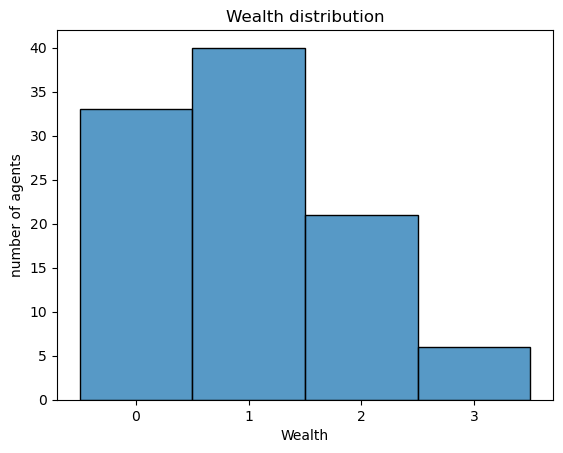

In [26]:
import matplotlib.ticker as ticker

agent_wealth = [a.wealth for a in model.agents]
# Create a histogram with seaborn
g = sns.histplot(agent_wealth, discrete=True)
g.set(
    title="Wealth distribution", xlabel="Wealth", ylabel="number of agents"
);  # The semicolon is just to avoid printing the object representation
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

## Adding Space
Display agents on a 2D grid.  
Use `CellAgent` subclass to handle interaction on grid.  
During each step, each agent will randomly move to one of its moore neighborhood and exchange money with random agent in its moore neighborhood like the first model.  
- `Network` in grid space seems interesting.
- [Mesa-Geo](https://mesa-geo.readthedocs.io/latest/): Extension of Mesa with geographic information.

### Visulization of agents' position on grid

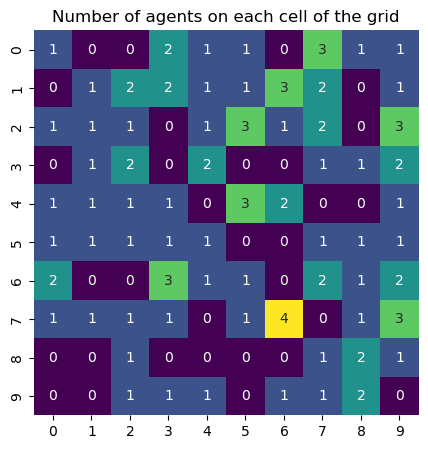

In [20]:
agent_counts = np.zeros((model.grid.width, model.grid.height))

for cell in model.grid.all_cells:
    agent_counts[cell.coordinate] = len(cell.agents)
# Plot using seaborn, with a visual size of 5x5
g = sns.heatmap(agent_counts, cmap="viridis", annot=True, cbar=False, square=True)
g.figure.set_size_inches(5, 5)
g.set(title="Number of agents on each cell of the grid");

## Collecting Data
Add `mesa.Datacollector` in the model definition.
- At the model level, measure the model’s [Gini Coefficient](https://en.wikipedia.org/wiki/Gini_coefficient), a measure of wealth inequality.
- At the agent level, collect every agent’s wealth at every step.

In [11]:
# Add function for model level collection
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    n = model.num_agents
    B = sum(xi * (n - i) for i, xi in enumerate(x)) / (n * sum(x))
    return 1 + (1 / n) - 2 * B

### Extract MoneyModel data in a Pandas dataframe step-wise

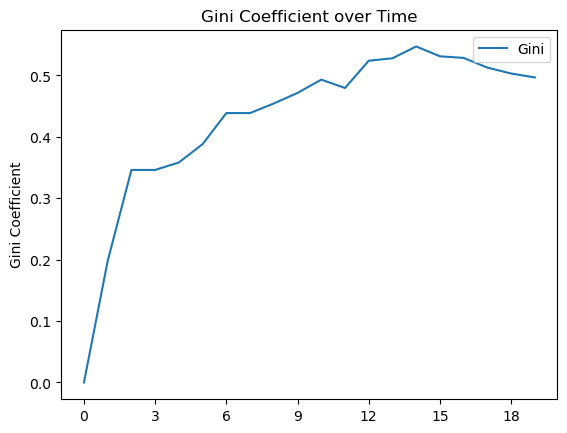

In [8]:
import matplotlib.ticker as ticker
# Extract MoneyModel data in a Pandas dataframe
gini = model.datacollector.get_model_vars_dataframe()

g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");
g.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

Data collector stores the data in a dictionary, with the step number as the key, and a dictionary of agent ID and variable value pairs as the value. The data collector then converts this dictionary into a DataFrame, which is why the index is a pair of (model step, agent ID).

In [9]:
# Extract MoneyAgent data in a Pandas dataframe
agent_wealth = model.datacollector.get_agent_vars_dataframe()
agent_wealth.head()

Wealth
Step AgentID        
1    1             1
     2             1
     3             1
     4             1
     5             1

## Agent Set

### Selecting
Use `agents.select` to separate the agents into rich and poor agents. If there are rich agents then they are the only ones who give money.  
Update the `step` and `give_money` method.  

### Group By
Uses `AgentSet.groupby` to group agents by their ethnicity attribute. This will give us a dictionary where the keys are the different ethnicities and the values are an `AgentSet`.  
In this case we will then use the `AgentSet` class and leverage its `shuffle_do` capability to then give money to the target groups.

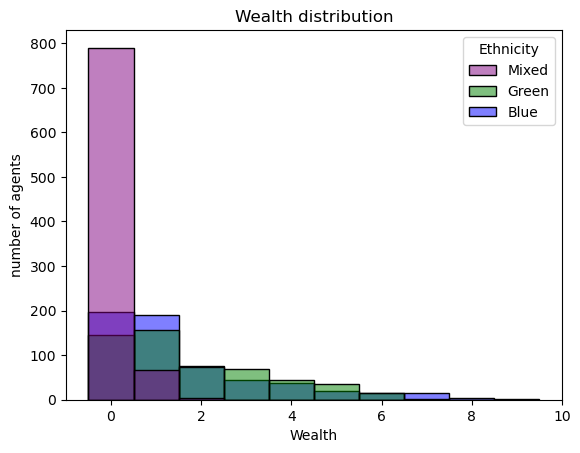

In [8]:
# get the data
data = model.datacollector.get_agent_vars_dataframe()
# assign histogram colors
palette = {"Green": "green", "Blue": "blue", "Mixed": "purple"}
g = sns.histplot(data=data, x="Wealth", hue="Ethnicity", discrete=True, palette=palette)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

## Dashboard & Interactive Visulization

Mesa’s grid visualizer works by looping over every cell in a grid, and generating a portrayal for every agent it finds. A portrayal is a dictionary (which can easily be turned into a JSON object) which tells Matplotlib the color and size of the scatterplot markers (each signifying an agent).   
The following code will draw each agent as a blue, filled circle, with a radius size of 50.

In [18]:
def agent_portrayal(agent):
    return {
        "color": "tab:blue",
        "size": 50,
    }

In addition to the portrayal method, we instantiate the model parameters, some of which are modifiable by user inputs. In this case, the number of agents, N, is specified as a slider of integers.

In [19]:
model_params = {
    "n": {
        "type": "SliderInt",
        "value": 50,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

In [27]:
# Create initial model instance
money_model = MoneyModel(n=50, width=10, height=10)  # keyword arguments

SpaceGraph = make_space_component(agent_portrayal)
GiniPlot = make_plot_component("Gini")

page = SolaraViz(
    money_model,
    components=[SpaceGraph, GiniPlot],
    model_params=model_params,
    name="Boltzmann Wealth Model",
)
# This is required to render the visualization in the Jupyter notebook
page

Cannot show ipywidgets in text